In [1]:
# Cell 1: Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# We only use cv2 for reading/writing, matplotlib for visualization, 
# and numpy for array manipulation.

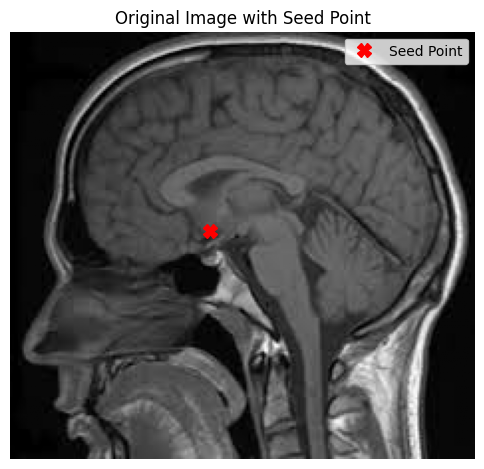

In [3]:
# Cell 2: Load an image or create a synthetic one for testing
image_path = "M5.jpeg" # Replace with your image path

# Try to read the image using OpenCV (Grayscale)
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# If the image doesn't exist, let's create a synthetic image with noise
# to demonstrate region growing and leakage.
if img is None:
    print("Image not found. Creating a synthetic noisy image for demonstration.")
    # Create a dark background
    img = np.zeros((200, 200), dtype=np.uint8)
    
    # Draw a lighter circle in the middle (Intensity ~150)
    for i in range(200):
        for j in range(200):
            if (i - 100)**2 + (j - 100)**2 < 40**2:
                img[i, j] = 150
                
    # Add a "leakage" bridge to another shape
    for i in range(90, 110):
        for j in range(140, 180):
            img[i, j] = 130  # Slightly darker bridge
            
    # Draw another shape connected by the bridge
    for i in range(70, 130):
        for j in range(170, 195):
            img[i, j] = 140
            
    # Add random Gaussian noise to the whole image
    noise = np.random.normal(0, 15, img.shape)
    img = np.clip(img + noise, 0, 255).astype(np.uint8)

# Define our seed point (x, y) - Note: x is row, y is column
# We will place the seed right in the center of our main circle
seed_point = (100, 100)

# Display the original image and mark the seed point
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.plot(seed_point[1], seed_point[0], 'rX', markersize=10, label='Seed Point')
plt.title("Original Image with Seed Point")
plt.legend()
plt.axis('off')
plt.show()

In [4]:
# Cell 3: Define the Region Growing Algorithm using basic Python and Numpy
def region_growing(image, seed, threshold):
    """
    Grows a region from a seed point based on an intensity threshold.
    """
    rows, cols = image.shape
    
    # Create a blank image for the segmented region (0 = background, 255 = region)
    segmented_img = np.zeros_like(image, dtype=np.uint8)
    
    # Create a boolean mask to keep track of visited pixels
    visited = np.zeros_like(image, dtype=bool)
    
    # Get the intensity of the seed point to compare others against
    # Converting to int to avoid uint8 overflow when calculating differences
    seed_intensity = int(image[seed[0], seed[1]])
    
    # List to act as a queue for points we need to process (Breadth-First Search)
    points_to_process = [seed]
    visited[seed[0], seed[1]] = True
    
    # 8-connected neighborhood (Up, Down, Left, Right, and 4 Diagonals)
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), 
                 (-1, -1), (-1, 1), (1, -1), (1, 1)]
    
    # Process points until the queue is empty
    while points_to_process:
        # Pop the first point in the list
        current_x, current_y = points_to_process.pop(0)
        
        # Add it to our segmented region
        segmented_img[current_x, current_y] = 255
        
        # Check all 8 neighbors
        for dx, dy in neighbors:
            nx, ny = current_x + dx, current_y + dy
            
            # Ensure the neighbor is within image boundaries
            if 0 <= nx < rows and 0 <= ny < cols:
                # If we haven't visited this pixel yet
                if not visited[nx, ny]:
                    visited[nx, ny] = True
                    
                    # Calculate the absolute difference in intensity
                    pixel_intensity = int(image[nx, ny])
                    intensity_diff = abs(pixel_intensity - seed_intensity)
                    
                    # If the difference is within our threshold, it belongs to the region
                    if intensity_diff <= threshold:
                        points_to_process.append((nx, ny))
                        
    return segmented_img

In [5]:
# Cell 4: Run the algorithm with different thresholds to analyze expansion and leakage
# Threshold 1: Too strict (Under-segmentation - stops too early due to noise)
thresh_low = 10
segmented_low = region_growing(img, seed_point, thresh_low)

# Threshold 2: Just right (Captures the main circle, stops at the darker bridge)
thresh_med = 30
segmented_med = region_growing(img, seed_point, thresh_med)

# Threshold 3: Too loose (Leakage - spills over the bridge into the second shape and background)
thresh_high = 60
segmented_high = region_growing(img, seed_point, thresh_high)

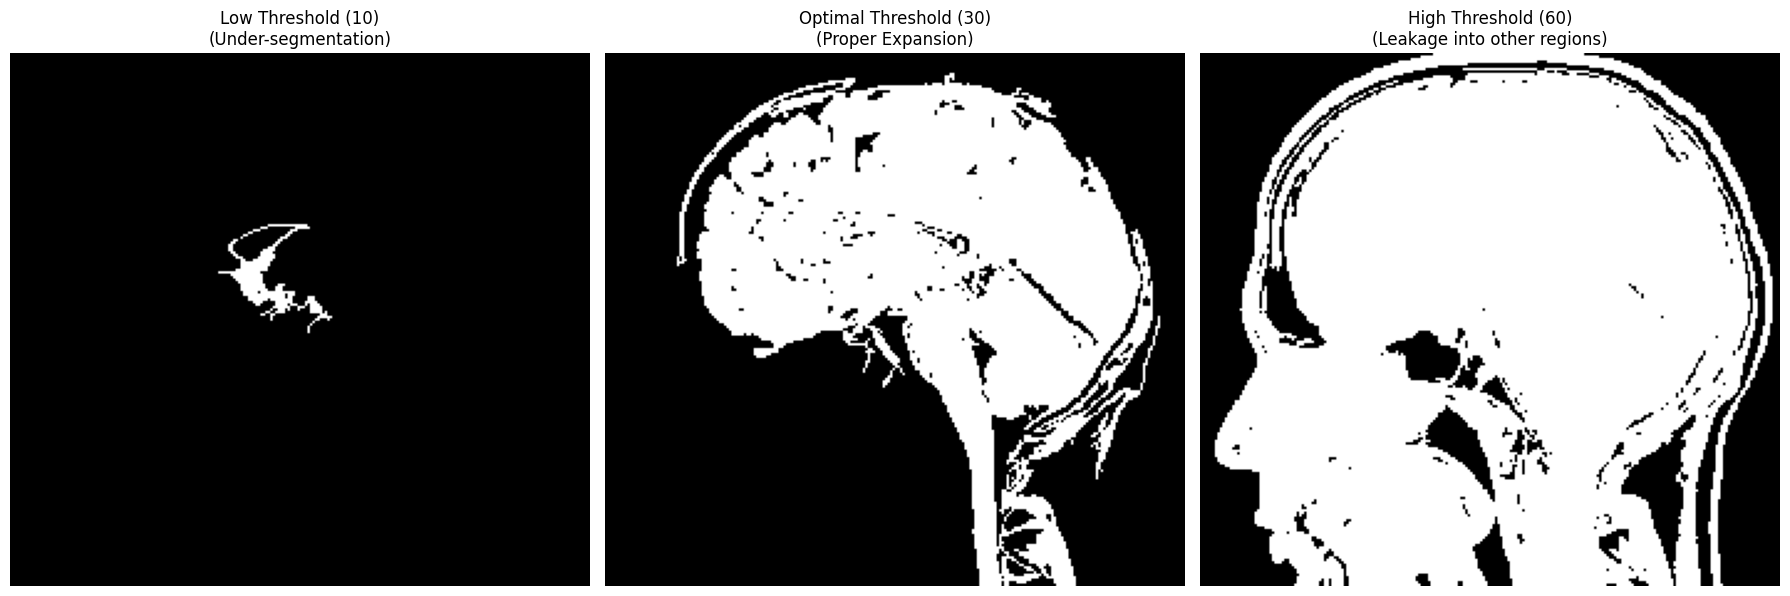

In [ ]:
# Cell 5: Display the results to compare the effects of thresholding
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(segmented_low, cmap='gray')
axes[0].set_title(f"Low Threshold ({thresh_low})\n(Under-segmentation)")
axes[0].axis('off')

axes[1].imshow(segmented_med, cmap='gray')
axes[1].set_title(f"Optimal Threshold ({thresh_med})\n(Proper Expansion)")
axes[1].axis('off')

axes[2].imshow(segmented_high, cmap='gray')
axes[2].set_title(f"High Threshold ({thresh_high})\n(Leakage into other regions)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Optional: Save the best output using OpenCV
# cv2.imwrite("segmented_output.jpg", segmented_med)

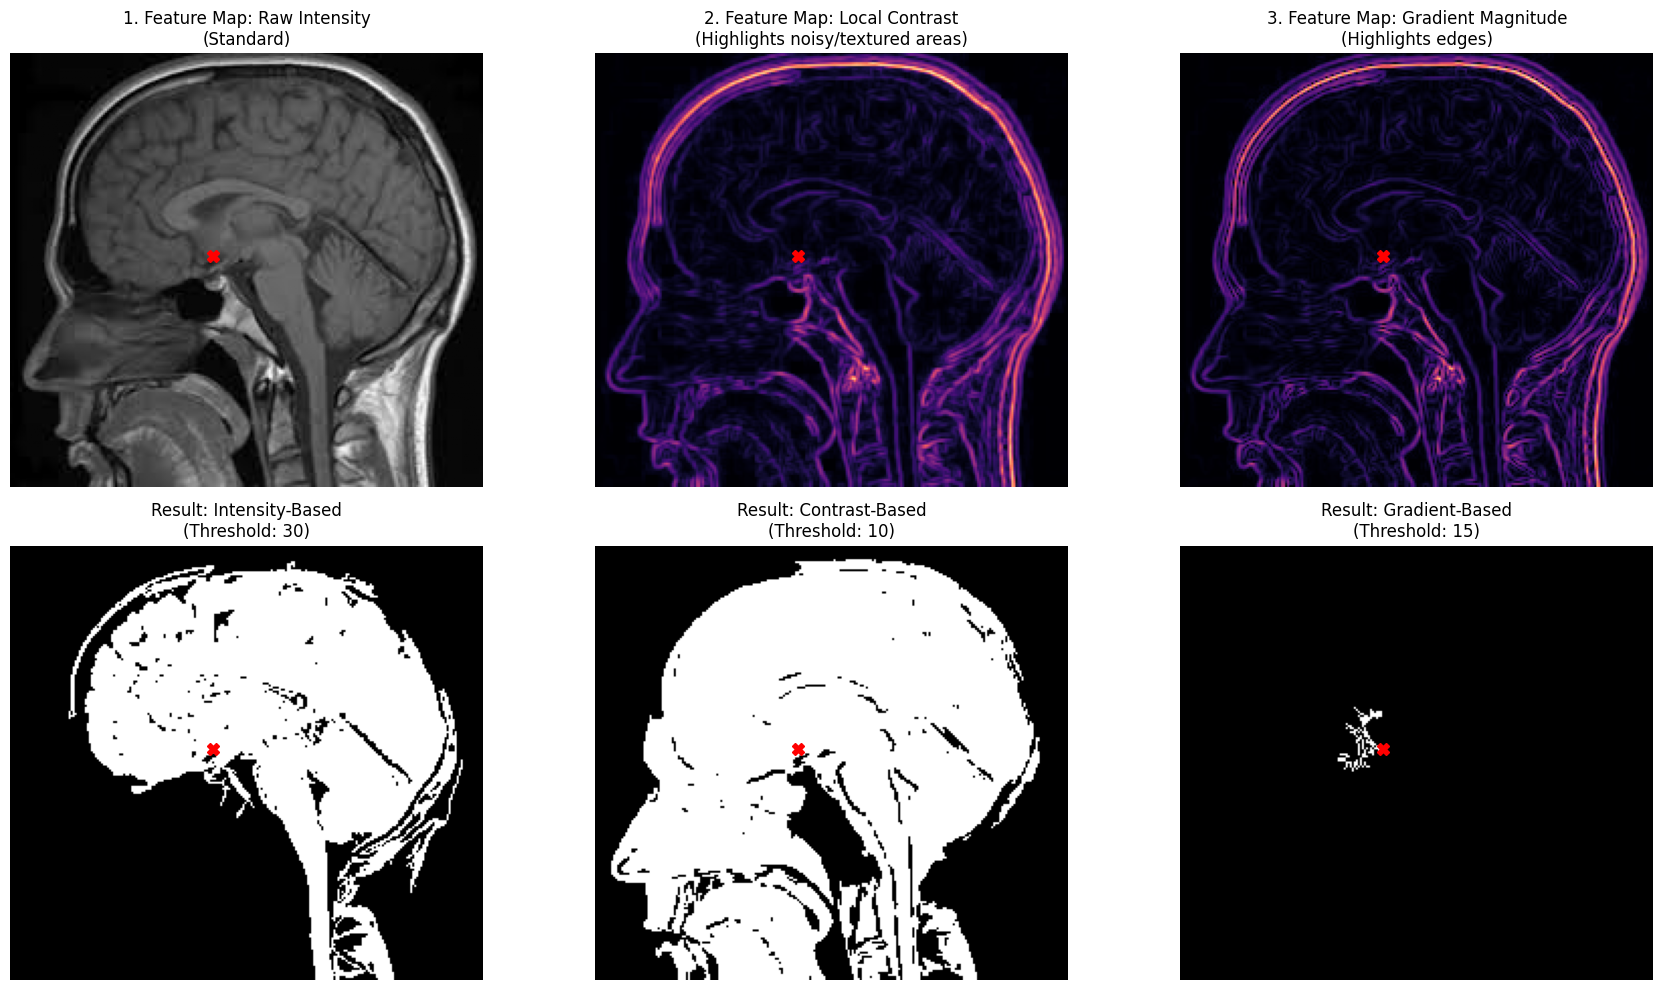

In [8]:
# Cell 7: Comparing Region Growing using Different Feature Maps

# 1. Create Feature Map: Local Contrast (Standard Deviation in a 3x3 window)
# We use float32 to prevent wrap-around issues with uint8 math
img_float = img.astype(np.float32)

# Fast way to compute local variance using OpenCV box filters: Var(X) = E(X^2) - (E(X))^2
mean_img = cv2.blur(img_float, (3, 3))
sq_img = cv2.blur(img_float**2, (3, 3))
variance_img = sq_img - mean_img**2

# Contrast is the standard deviation (sqrt of variance)
contrast_map = np.sqrt(np.maximum(variance_img, 0)) 

# 2. Create Feature Map: Gradient Magnitude (Edges) using Sobel Operators
sobelx = cv2.Sobel(img_float, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_float, cv2.CV_64F, 0, 1, ksize=3)
gradient_map = np.sqrt(sobelx**2 + sobely**2)

# 3. Generic Region Growing Function
def region_growing_generic(feature_map, seed, threshold):
    """
    Runs region growing on ANY feature map (Intensity, Contrast, Gradient, etc.)
    """
    rows, cols = feature_map.shape
    segmented_img = np.zeros((rows, cols), dtype=np.uint8)
    visited = np.zeros((rows, cols), dtype=bool)
    
    # Get the feature value at the seed point
    seed_val = float(feature_map[seed[0], seed[1]])
    
    points_to_process = [seed]
    visited[seed[0], seed[1]] = True
    
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), 
                 (-1, -1), (-1, 1), (1, -1), (1, 1)]
    
    while points_to_process:
        cx, cy = points_to_process.pop(0)
        segmented_img[cx, cy] = 255
        
        for dx, dy in neighbors:
            nx, ny = cx + dx, cy + dy
            if 0 <= nx < rows and 0 <= ny < cols:
                if not visited[nx, ny]:
                    visited[nx, ny] = True
                    
                    val = float(feature_map[nx, ny])
                    # Compare the feature value to the seed's feature value
                    if abs(val - seed_val) <= threshold:
                        points_to_process.append((nx, ny))
                        
    return segmented_img

# 4. Run the segmentations with thresholds tuned for each specific feature scale
seg_intensity = region_growing_generic(img_float, seed_point, threshold=30)
seg_contrast  = region_growing_generic(contrast_map, seed_point, threshold=10)
seg_gradient  = region_growing_generic(gradient_map, seed_point, threshold=15)

# 5. Visualize Intermediate Feature Maps and Final Comparisons
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Top row: Show the intermediate feature maps (using colors to highlight differences)
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title("1. Feature Map: Raw Intensity\n(Standard)")

axes[0, 1].imshow(contrast_map, cmap='magma')
axes[0, 1].set_title("2. Feature Map: Local Contrast\n(Highlights noisy/textured areas)")

axes[0, 2].imshow(gradient_map, cmap='magma')
axes[0, 2].set_title("3. Feature Map: Gradient Magnitude\n(Highlights edges)")

# Bottom row: Show the resulting segmentations
axes[1, 0].imshow(seg_intensity, cmap='gray')
axes[1, 0].set_title(f"Result: Intensity-Based\n(Threshold: 30)")

axes[1, 1].imshow(seg_contrast, cmap='gray')
axes[1, 1].set_title(f"Result: Contrast-Based\n(Threshold: 10)")

axes[1, 2].imshow(seg_gradient, cmap='gray')
axes[1, 2].set_title(f"Result: Gradient-Based\n(Threshold: 15)")

for ax in axes.flatten():
    ax.plot(seed_point[1], seed_point[0], 'rX', markersize=8) # Keep seed visible
    ax.axis('off')

plt.tight_layout()
plt.show()